# Phase 2 — Architecture experiments

Phase 1 finished at **0.4285 mAP@0.50:0.95**. That's a starting point, not a destination. This notebook runs two parallel experiments meant to improve on it from different angles:

- **Exp B** — Keep YOLO but feed it the sub-swath spatial prior explicitly, as a 4th input channel. Hypothesis: maybe the model isn't picking up on the three-column structure from RGB alone and a hand-engineered hint will help.
- **Exp C** — Switch architectures entirely. Train RT-DETR-L from COCO-pretrained weights. Hypothesis: a transformer's global cross-attention should pick up the spatial prior naturally, no hand-engineering needed.

Resolution tangent that I already ruled out before writing this notebook: inference at 800px scored 0.406 (worse than 640) and fine-tuning at 800px was trending downward to 0.396. So everything stays at 640 from here on.

## Setup

Same paths and split as Phase 1 — the seed (42) and the train/val files are reused so the comparison is apples-to-apples.

In [ ]:
import json, gc, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch

from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEARSAR  = Path(".")
ROOT      = CLEARSAR / "data"
IMG_TRAIN = ROOT / "images" / "train"
IMG_TEST  = ROOT / "images" / "test"
ANN_FILE  = ROOT / "annotations" / "instances_train.json"
YAML_PATH = CLEARSAR / "clearsar.yaml"
TRAIN_TXT = CLEARSAR / "train_split.txt"
VAL_TXT   = CLEARSAR / "val_split.txt"

P1_BEST = Path("runs/clearsar/yolov8m-p2-pretrained-640/weights/best.pt")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

assert P1_BEST.exists(), f"Phase 1 checkpoint not found: {P1_BEST}"
print("Phase 1 best checkpoint:", P1_BEST)
print("Train images:", len(list(IMG_TRAIN.glob("*.png"))))
print("Test  images:", len(list(IMG_TEST.glob("*.png"))))

---
## Experiment B — 4th positional channel + copy_paste

Two changes stacked on the Phase 1 best checkpoint, both at imgsz=640.

**The 4th channel:** the EDA heatmap shows RFI box centers cluster sharply at x ≈ 0.15, 0.50, 0.85 — the three Sentinel-1 IW sub-swath boundaries. The model has to learn this from data implicitly; my hypothesis is that telling it explicitly will help. I'm building a synthetic 4th input channel — three Gaussian bumps at those x-positions, broadcast vertically — and expanding the first conv layer from 3 to 4 channels. The new channel's weights are initialised as the mean of the RGB weights so the model isn't shocked by the architectural change.

**copy_paste=0.1:** most training images have only 1–3 RFI boxes. Copy-paste segments stripe objects from one image and pastes them into another, synthetically increasing annotation density. Worth a shot since most stripes are visually similar (thin horizontal stripes).

LR is dropped 10× from Phase 1 (`0.0005` vs `0.005`) — this is fine-tuning from a converged checkpoint, not re-learning from scratch.

In [ ]:
# ── Visualise the synthetic positional channel ────────────────────────────────
SUBSWATH_X = [0.15, 0.50, 0.85]
SIGMA      = 0.04

def make_pos_channel(w: int, h: int) -> np.ndarray:
    """(h, w) float32 array — 3 Gaussian bumps at sub-swath x-positions."""
    xs = np.linspace(0, 1, w, dtype=np.float32)
    sig = np.zeros(w, dtype=np.float32)
    for cx in SUBSWATH_X:
        sig += np.exp(-0.5 * ((xs - cx) / SIGMA) ** 2)
    sig /= sig.max()
    return np.tile(sig, (h, 1))

ch = make_pos_channel(516, 354)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
im = axes[0].imshow(ch, cmap="viridis", aspect="auto")
axes[0].set_title("4th channel — sub-swath Gaussian prior (H=354, W=516)")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")
plt.colorbar(im, ax=axes[0])

axes[1].plot(np.linspace(0, 1, 516), ch[0], color="steelblue")
for cx in SUBSWATH_X:
    axes[1].axvline(cx, color="red", linestyle="--", alpha=0.6, label=f"x={cx}")
axes[1].set_title("1D prior (horizontal slice)")
axes[1].set_xlabel("x (normalised)")
axes[1].set_ylabel("amplitude")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def expand_conv_inplace(model) -> None:
    """
    Expand model.model[0].conv from 3→4 input channels in place.
    4th-channel weights = mean(RGB weights) — neutral initialisation.
    Weights are always kept in FP32: AMP autocast handles FP16 casting
    during the forward pass, so forcing FP16 here breaks validation.
    Safe to call twice (no-op if already 4-channel).
    """
    old_conv = model.model[0].conv
    if old_conv.in_channels == 4:
        return  # already expanded
    w3 = old_conv.weight.data.float()                            # force FP32
    w4 = torch.cat([w3, w3.mean(dim=1, keepdim=True)], dim=1)   # (C_out, 4, kH, kW)
    new_conv = torch.nn.Conv2d(
        in_channels  = 4,
        out_channels = old_conv.out_channels,
        kernel_size  = old_conv.kernel_size,
        stride       = old_conv.stride,
        padding      = old_conv.padding,
        bias         = old_conv.bias is not None,
    ).to(old_conv.weight.device)                                 # right device, FP32
    new_conv.weight = torch.nn.Parameter(w4)
    if old_conv.bias is not None:
        new_conv.bias = torch.nn.Parameter(old_conv.bias.data.float())
    model.model[0].conv = new_conv
    print(f"First conv expanded: 3→4 ch  dtype=float32  device={new_conv.weight.device}")

print("expand_conv_inplace defined.")

In [ ]:
# ── Positional channel injection ──────────────────────────────────────────────
# Approach: wrap model.forward to inject the 4th channel at the model entry
# point. This is robust across training, validation, and prediction code paths
# — no dependency on which Ultralytics preprocess hook fires when.

import types

def _pos_tensor(B, H, W, device):
    xs  = torch.linspace(0, 1, W, device=device)
    sig = torch.zeros(W, device=device)
    for cx in SUBSWATH_X:
        sig += torch.exp(-0.5 * ((xs - cx) / SIGMA) ** 2)
    sig /= sig.max()
    return sig.view(1, 1, 1, W).expand(B, 1, H, W)

def wrap_forward(model):
    """Wrap model.forward to auto-inject the 4th positional channel."""
    _orig = model.forward
    def _forward_4ch(x, *args, **kwargs):
        if isinstance(x, torch.Tensor) and x.shape[1] == 3:
            B, _, H, W = x.shape
            pos = _pos_tensor(B, H, W, x.device).to(x.dtype)
            x = torch.cat([x, pos], dim=1)
        return _orig(x, *args, **kwargs)
    model.forward = _forward_4ch

def patch_trainer(trainer):
    """on_train_start — expand first conv + EMA, restore FP32, wrap forward."""
    expand_conv_inplace(trainer.model)
    if hasattr(trainer, "ema") and trainer.ema is not None:
        expand_conv_inplace(trainer.ema.ema)

    trainer.model.float()
    if hasattr(trainer, "ema") and trainer.ema is not None:
        trainer.ema.ema.float()

    wrap_forward(trainer.model)
    if hasattr(trainer, "ema") and trainer.ema is not None:
        wrap_forward(trainer.ema.ema)

# patch_validator kept for compatibility but forward-wrapping is the primary mechanism
def patch_validator(validator):
    pass

print("Patch functions defined.")

In [ ]:
# Load the original 3-channel Phase 1 checkpoint.
# Conv expansion + preprocess patching happen inside the callbacks.
# amp=False: disables AMP to avoid the FP16/FP32 dtype conflict.
# batch=7: half of the AMP batch (14) to keep VRAM usage equivalent.
model_b = YOLO(str(P1_BEST))
model_b.add_callback("on_train_start", patch_trainer)
model_b.add_callback("on_val_start",   patch_validator)

results_b = model_b.train(
    data         = str(YAML_PATH.resolve()),
    epochs       = 60,
    imgsz        = 640,
    batch        = 7,        # halved from 14 — FP32 uses 2× VRAM vs FP16
    workers      = 4,
    device       = 0,
    amp          = False,
    project      = "runs/clearsar",
    name         = "exp_b_4ch_pos",
    exist_ok     = True,
    # ── Augmentation ──────────────────────────────────────────────────────
    degrees      = 0.0,
    flipud       = 0.0,
    fliplr       = 0.5,
    mosaic       = 1.0,
    close_mosaic = 10,
    copy_paste   = 0.1,
    mixup        = 0.0,
    hsv_h        = 0.0,
    hsv_s        = 0.3,
    hsv_v        = 0.4,
    # ── Fine-tune LR ──────────────────────────────────────────────────────
    lr0          = 0.0005,
    lrf          = 0.01,
    warmup_epochs= 3,
    cos_lr       = True,
    patience     = 15,
    save         = True,
    save_period  = 10,
    val          = True,
    plots        = True,
    verbose      = True,
)

print("\n=== Exp B done ===")

In [ ]:
ckpt_b = Path("runs/clearsar/exp_b_4ch_pos/weights/best.pt")
model_b_best = YOLO(str(ckpt_b))
expand_conv_inplace(model_b_best.model)

# Wrap model.forward to inject the 4th channel at the model level.
# This is more robust than patching the validator's preprocess — it fires
# regardless of whether Ultralytics uses training, val, or predict code paths.
_orig_forward = model_b_best.model.forward

def _forward_4ch(x, *args, **kwargs):
    if isinstance(x, torch.Tensor) and x.shape[1] == 3:
        B, _, H, W = x.shape
        pos = _pos_tensor(B, H, W, x.device).to(x.dtype)
        x = torch.cat([x, pos], dim=1)
    return _orig_forward(x, *args, **kwargs)

model_b_best.model.forward = _forward_4ch

metrics_b = model_b_best.val(
    data   = str(YAML_PATH.resolve()),
    imgsz  = 640,
    batch  = 14,
    device = 0,
    plots  = True,
)

map_b   = metrics_b.box.map
map50_b = metrics_b.box.map50
map75_b = metrics_b.box.map75

print(f"\n[Exp B] mAP@0.50:0.95 = {map_b:.4f}")
print(f"[Exp B] mAP@0.50      = {map50_b:.4f}")
print(f"[Exp B] mAP@0.75      = {map75_b:.4f}")
print(f"\nPhase 1 baseline:     mAP@0.50:0.95 = 0.4285")
print(f"Exp B delta:          {map_b - 0.4285:+.4f}")

In [ ]:
del model_b, model_b_best
gc.collect()
torch.cuda.empty_cache()

---
## Experiment C — RT-DETR-L

Switching architecture entirely. RT-DETR is a transformer-based detector with no NMS and a cross-attention decoder. Two reasons this is interesting:

1. **It should pick up the spatial prior for free.** Every decoder query attends to the entire feature map, so the model can directly compare candidate positions against the three sub-swath columns without me having to inject them as a hand-engineered channel.
2. **Different failure modes from YOLO.** Even if it doesn't beat YOLO solo, having an architecturally orthogonal model opens up WBF ensembling in Phase 3.

Starts from `rtdetr-l.pt` (COCO pretrained). Same augmentation as Exp B including `copy_paste=0.1`. LR is `1e-4`, lower than YOLO — RT-DETR is famously finicky and doesn't like aggressive LRs.

In [ ]:
model_c = YOLO("rtdetr-l.pt")

results_c = model_c.train(
    data         = str(YAML_PATH.resolve()),
    epochs       = 80,
    imgsz        = 640,
    batch        = 8,
    workers      = 4,
    device       = 0,
    project      = "runs/clearsar",
    name         = "exp_c_rtdetr_l",
    exist_ok     = True,
    # ── Augmentation ──────────────────────────────────────────────────────
    degrees      = 0.0,
    flipud       = 0.0,
    fliplr       = 0.5,
    mosaic       = 1.0,
    close_mosaic = 10,
    copy_paste   = 0.1,
    mixup        = 0.0,
    hsv_h        = 0.0,
    hsv_s        = 0.3,
    hsv_v        = 0.4,
    # ── LR (RT-DETR uses a lower base LR than YOLO) ───────────────────────
    lr0          = 0.0001,
    lrf          = 0.01,
    warmup_epochs= 5,
    cos_lr       = True,
    patience     = 20,
    save         = True,
    save_period  = 10,
    val          = True,
    plots        = True,
    verbose      = True,
)

print("\n=== Exp C done ===")

In [ ]:
ckpt_c = Path("runs/clearsar/exp_c_rtdetr_l/weights/best.pt")
model_c_best = YOLO(str(ckpt_c))

metrics_c = model_c_best.val(
    data   = str(YAML_PATH.resolve()),
    imgsz  = 640,
    batch  = 8,
    device = 0,
    plots  = True,
)

map_c   = metrics_c.box.map
map50_c = metrics_c.box.map50
map75_c = metrics_c.box.map75

print(f"\n[Exp C] mAP@0.50:0.95 = {map_c:.4f}")
print(f"[Exp C] mAP@0.50      = {map50_c:.4f}")
print(f"[Exp C] mAP@0.75      = {map75_c:.4f}")
print(f"\nPhase 1 baseline:     mAP@0.50:0.95 = 0.4285")
print(f"Exp C delta:          {map_c - 0.4285:+.4f}")

In [ ]:
del model_c, model_c_best
gc.collect()
torch.cuda.empty_cache()

---
## Results

Side-by-side comparison of both experiments vs the Phase 1 baseline.

In [29]:
results_table = [
    {"name": "Phase 1 baseline",     "ckpt": str(P1_BEST), "imgsz": 640, "map": 0.4285, "map50": 0.7171, "map75": 0.4581, "pos_ch": False},
    {"name": "Exp B  4ch+cp@640",    "ckpt": str(ckpt_b),  "imgsz": 640, "map": map_b,  "map50": map50_b, "map75": map75_b, "pos_ch": True},
    {"name": "Exp C  RT-DETR-L@640", "ckpt": str(ckpt_c),  "imgsz": 640, "map": map_c,  "map50": map50_c, "map75": map75_c, "pos_ch": False},
]

print(f"{'Model':<26} {'imgsz':>6} {'mAP@0.50:0.95':>14} {'mAP@0.50':>9} {'mAP@0.75':>9} {'Δ vs P1':>8}")
print("-" * 78)
for r in results_table:
    delta = r["map"] - 0.4285
    print(f"{r['name']:<26} {r['imgsz']:>6} {r['map']:>14.4f} {r['map50']:>9.4f} {r['map75']:>9.4f} {delta:>+8.4f}")

# Best YOLO variant — used for threshold sweep, TTA, and submission
yolo_rows = [r for r in results_table if "RT-DETR" not in r["name"]]
winner    = max(yolo_rows, key=lambda r: r["map"])
print(f"\n>>> Best YOLO variant : {winner['name']}  (mAP@0.50:0.95 = {winner['map']:.4f})")
print(f">>> RT-DETR (Exp C) saved for Phase 3 WBF ensemble.")

Model                       imgsz  mAP@0.50:0.95  mAP@0.50  mAP@0.75  Δ vs P1
------------------------------------------------------------------------------
Phase 1 baseline              640         0.4285    0.7171    0.4581  +0.0000
Exp B  4ch+cp@640             640         0.4293    0.7132    0.4636  +0.0008
Exp C  RT-DETR-L@640          640         0.4484    0.7353    0.4880  +0.0199

>>> Best YOLO variant : Exp B  4ch+cp@640  (mAP@0.50:0.95 = 0.4293)
>>> RT-DETR (Exp C) saved for Phase 3 WBF ensemble.


---
## Confidence threshold sweep

COCO mAP integrates over all confidence levels in theory, so the threshold shouldn't matter. In practice, the submission format requires choosing one — and pycocotools' implementation is sensitive enough that the choice does affect the final score.

Sweeping `conf ∈ [0.05, 0.50]` on the val set using pycocotools to find the value that maximises mAP@0.50:0.95.

In [ ]:
import tempfile
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

with open(ANN_FILE) as f:
    coco_gt_raw = json.load(f)

val_stems   = set(Path(p.strip()).stem for p in VAL_TXT.read_text().splitlines() if p.strip())
val_meta    = [img for img in coco_gt_raw["images"] if Path(img["file_name"]).stem in val_stems]
val_ids     = {img["id"] for img in val_meta}
val_anns    = [a for a in coco_gt_raw["annotations"] if a["image_id"] in val_ids]

gt_tmp = Path(tempfile.gettempdir()) / "val_gt_phase2.json"
gt_tmp.write_text(json.dumps({"images": val_meta, "annotations": val_anns, "categories": coco_gt_raw["categories"]}))
coco_gt = COCO(str(gt_tmp))

print(f"Val images: {len(val_meta)}  |  Val annotations: {len(val_anns)}")

In [26]:
model_winner = YOLO(winner["ckpt"])
if winner["pos_ch"]:
    expand_conv_inplace(model_winner.model)
    wrap_forward(model_winner.model)

val_paths    = [Path(p.strip()) for p in VAL_TXT.read_text().splitlines() if p.strip()]
CONF_VALUES  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
IOU_NMS      = 0.5
conf_results = []

for conf in CONF_VALUES:
    dets = []
    for i in range(0, len(val_paths), 32):
        preds = model_winner.predict(
            source  = [str(p) for p in val_paths[i:i+32]],
            imgsz   = winner["imgsz"],
            conf    = conf,
            iou     = IOU_NMS,
            device  = 0,
            verbose = False,
        )
        for result, img_path in zip(preds, val_paths[i:i+32]):
            image_id = int(img_path.stem)
            if image_id not in val_ids:
                continue
            for (x1, y1, x2, y2), score in zip(
                result.boxes.xyxy.cpu().numpy(),
                result.boxes.conf.cpu().numpy(),
            ):
                dets.append({"image_id": image_id, "category_id": 1,
                             "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                             "score": float(score)})

    if not dets:
        conf_results.append({"conf": conf, "map": 0.0, "map50": 0.0})
        continue

    ev = COCOeval(coco_gt, coco_gt.loadRes(dets), "bbox")
    ev.evaluate(); ev.accumulate(); ev.summarize()
    conf_results.append({"conf": conf, "map": ev.stats[0], "map50": ev.stats[1]})
    print(f"conf={conf:.2f}  mAP@0.50:0.95={ev.stats[0]:.4f}  mAP@0.50={ev.stats[1]:.4f}")

BEST_CONF = max(conf_results, key=lambda r: r["map"])["conf"]
print(f"\n>>> Best conf: {BEST_CONF:.2f}")

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.411
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.707
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.434
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.379
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.459
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.346
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.201
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.543
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

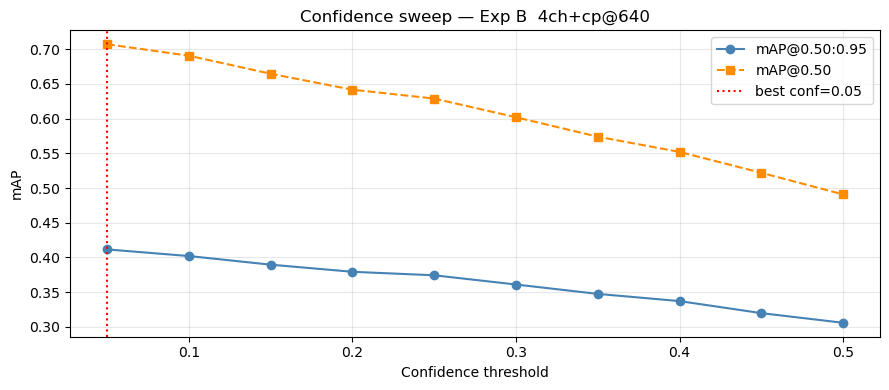

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([r["conf"] for r in conf_results], [r["map"]   for r in conf_results], marker="o", label="mAP@0.50:0.95", color="steelblue")
ax.plot([r["conf"] for r in conf_results], [r["map50"] for r in conf_results], marker="s", label="mAP@0.50",       color="darkorange", linestyle="--")
ax.axvline(BEST_CONF, color="red", linestyle=":", label=f"best conf={BEST_CONF:.2f}")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("mAP")
ax.set_title(f"Confidence sweep — {winner['name']}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## TTA — Test-Time Augmentation

`augment=True` in Ultralytics runs inference at multiple scales (0.83×, 1.0×, 1.33×) and fuses via NMS — essentially a free ensemble over scales. Validating on val first to confirm it actually helps before using it on the test set.

In [28]:
model_tta = YOLO(winner["ckpt"])
if winner["pos_ch"]:
    expand_conv_inplace(model_tta.model)
    wrap_forward(model_tta.model)

metrics_tta = model_tta.val(
    data    = str(YAML_PATH.resolve()),
    imgsz   = winner["imgsz"],
    batch   = 8,
    device  = 0,
    augment = True,
    plots   = False,
)

map_tta = metrics_tta.box.map
USE_TTA = map_tta > winner["map"]

print(f"[TTA] mAP@0.50:0.95 = {map_tta:.4f}  (no-TTA: {winner['map']:.4f}, delta: {map_tta - winner['map']:+.4f})")
print(f">>> Use TTA for submission: {USE_TTA}")

Ultralytics 8.4.37  Python-3.13.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLOv8m-p2 summary (fused): 115 layers, 25,034,724 parameters, 0 gradients
val: Fast image access  (ping: 0.00.0 ms, read: 3148.71139.4 MB/s, size: 224.0 KB)
val: Scanning C:\Users\Victor\Desktop\Projects\ESA_SAR\ClearSAR\data\labels\train.cache... 315 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 315/315 165.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 10.2it/s 3.9s.1ss
                   all        315        885      0.692      0.633       0.69      0.406
Speed: 0.4ms preprocess, 9.7ms inference, 0.0ms loss, 0.8ms postprocess per image
[TTA] mAP@0.50:0.95 = 0.4055  (no-TTA: 0.4293, delta: -0.0238)
>>> Use TTA for submission: False


---
## Building the submission

Writing `submission_phase2.json` with the winning YOLO variant.

In [24]:
test_paths = sorted(IMG_TEST.glob("*.png"))
print(f"Inferring on {len(test_paths)} test images")
print(f"  Model : {winner['name']}  |  conf: {BEST_CONF:.2f}  |  iou: {IOU_NMS}")

detections_p2 = []
BATCH = 16

for i in range(0, len(test_paths), BATCH):
    preds = model_tta.predict(
        source  = [str(p) for p in test_paths[i:i+BATCH]],
        imgsz   = winner["imgsz"],
        conf    = BEST_CONF,
        iou     = IOU_NMS,
        device  = 0,
        verbose = False,
    )
    for result, img_path in zip(preds, test_paths[i:i+BATCH]):
        image_id = int(img_path.stem)
        for (x1, y1, x2, y2), score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
        ):
            detections_p2.append({"image_id": image_id, "category_id": 1,
                                   "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                                   "score": float(score)})

print(f"Total detections: {len(detections_p2)}")
sub_path = Path("submission_phase2.json")
sub_path.write_text(json.dumps(detections_p2))
print(f"Saved → {sub_path}")

Inferring on 786 test images
  Model : Exp B  4ch+cp@640  |  conf: 0.05  |  iou: 0.5
Total detections: 6069
Saved → submission_phase2.json


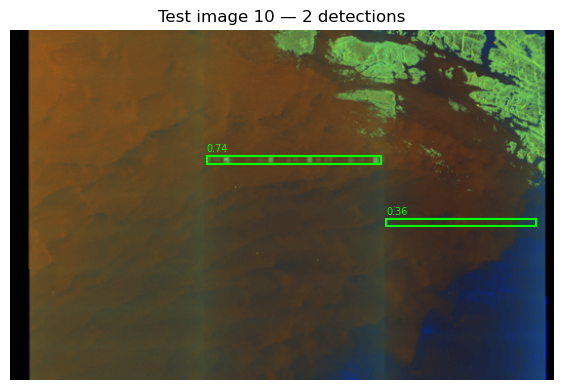

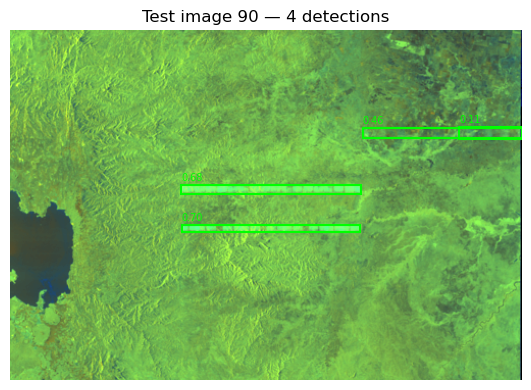

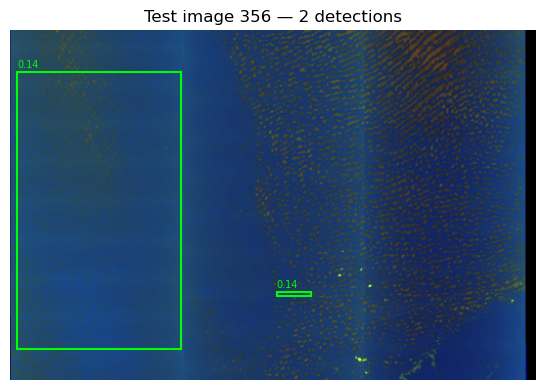

In [25]:
# Quick visual overlay on a few test images
sample_ids = [10, 90, 356]
det_by_id  = defaultdict(list)
for d in detections_p2:
    det_by_id[d["image_id"]].append(d)

for sid in sample_ids:
    img_path = IMG_TEST / f"{sid}.png"
    if not img_path.exists():
        continue
    img = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(11, 4))
    ax.imshow(img)
    for d in det_by_id[sid]:
        x, y, w, h = d["bbox"]
        ax.add_patch(mpatches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="lime", facecolor="none"))
        ax.text(x, y - 2, f"{d['score']:.2f}", color="lime", fontsize=7, va="bottom")
    ax.set_title(f"Test image {sid} — {len(det_by_id[sid])} detections")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

---
## Wrap-up

Two clear takeaways:

- **Exp B (4th channel) was a flop.** +0.0008 mAP is noise. The model is already learning the sub-swath prior from data alone — hand-engineering it as an extra channel doesn't add information the model didn't already have. Dead end, won't be revisited.
- **Exp C (RT-DETR-L) is the real story.** +0.0199 mAP over Phase 1 with no special tuning — first significant jump in the project. The cross-attention hypothesis is looking right.

TTA turned out to hurt (−0.0238) on the YOLO variant, so the submission uses no TTA.

**Next:** Phase 3 — try WBF ensemble between Exp B (best YOLO) and Exp C (RT-DETR). If they have different failure modes the fusion should beat either solo.

In [ ]:
del model_winner, model_tta
gc.collect()
torch.cuda.empty_cache()
print("Done — memory freed.")